# 🏠 NSW Housing Data Pipeline
**The granular one.** NSW Valuer-General publishes **transaction-level** sales (every sale: address, price, land area) — so unlike VIC/QLD we get true suburb medians, price distributions and price-per-m² of land.

**Sources:** NSW Valuer-General · NSW DCJ Rent & Sales · ABS · RBA · ASX

---

## 0 · Setup

In [1]:
import os, subprocess, sys
os.environ["NSW_SALES_YEARS"] = "2023,2024,2025"   # which VG sale years to ingest
subprocess.check_call([sys.executable, "-m", "pip", "install",
    "requests", "openpyxl", "pandas", "lxml", "beautifulsoup4",
    "statsmodels", "matplotlib", "--quiet"])
import sys, pathlib
HERE = pathlib.Path().resolve()
for parent in [HERE, *HERE.parents]:
    if (parent / "nsw_housing" / "__init__.py").exists():
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        print(f"Package found at: {parent}")
        break

Package found at: C:\Users\henry\Desktop\career\Resumes\github\nsw-housing-data


## 1 · Initialise the database

In [2]:
from nsw_housing.core import init_db, DB_PATH, get_conn
import pandas as pd, numpy as np
init_db()
print(f"Database: {DB_PATH}")

C:\Users\henry\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
2026-06-08 12:09:47 [INFO] nsw_housing.core: Database ready: C:\Users\henry\Desktop\career\Resumes\github\nsw-housing-data\nsw_housing.db


Database: C:\Users\henry\Desktop\career\Resumes\github\nsw-housing-data\nsw_housing.db


## 2 · Connector: NSW Valuer-General transaction-level sales
Every individual residential sale, 2023–2025. Cached on disk, so re-runs are instant.

In [3]:
from nsw_housing import vg_sales
print(f"New sales: {vg_sales.run():,}")

2026-06-08 12:09:47 [INFO] nsw_housing.vg_sales: NSW VG sales 2023: downloading...
2026-06-08 12:09:51 [INFO] nsw_housing.vg_sales:   2023: 156,068 residential sales parsed -> 31 new (4s)
2026-06-08 12:09:51 [INFO] nsw_housing.vg_sales: NSW VG sales 2024: downloading...
2026-06-08 12:09:55 [INFO] nsw_housing.vg_sales:   2024: 191,475 residential sales parsed -> 40 new (4s)
2026-06-08 12:09:55 [INFO] nsw_housing.vg_sales: NSW VG sales 2025: downloading...
2026-06-08 12:10:00 [INFO] nsw_housing.vg_sales:   2025: 208,654 residential sales parsed -> 28 new (5s)
2026-06-08 12:10:00 [INFO] nsw_housing.vg_sales: NSW VG: 99 new sales inserted across [2023, 2024, 2025]


New sales: 99


In [4]:
conn = get_conn()
df = pd.read_sql_query(
    "SELECT dwelling_type, COUNT(*) AS sales, "
    "       CAST(AVG(price) AS INT) AS avg_price "
    "FROM sales WHERE suburb IN ('MOSMAN','PARRAMATTA','DUBBO','BROKEN HILL') "
    "GROUP BY dwelling_type", conn)
conn.close()
print("Sample — individual sales aggregate to true suburb medians:")
df

Sample — individual sales aggregate to true suburb medians:


,dwelling_type,sales,avg_price
0,house,5428,1546414
1,unit,3847,1184738


## 3 · Connector: NSW DCJ median rents (LGA + postcode)

In [5]:
from nsw_housing import rent
print(f"New rent rows: {rent.run():,}")

2026-06-08 12:10:01 [INFO] nsw_housing.rent: Fetching DCJ rent tables (2026-Q1): https://dcj.nsw.gov.au/content/dam/dcj/dcj-website/documents/about-us/families-and-communities-statistics/housing-and-rent-sales/rent-tables-march-2026-quarter.xlsx
2026-06-08 12:10:13 [INFO] nsw_housing.rent:   Sheet 'LGA' (lga): 13,058 rows
2026-06-08 12:10:17 [INFO] nsw_housing.rent:   Sheet 'Postcode' (postcode): 3,992 rows
2026-06-08 12:10:17 [INFO] nsw_housing.rent: DCJ rent: 17,050 rows -> 0 new inserted


New rent rows: 0


## 4 · Macro connectors: ABS · RBA · cash rate · capitals · ASX

In [6]:
from nsw_housing import abs as abs_mod, rba, cashrate, capitals, asx
for name, fn in [("abs", abs_mod.run), ("rba", rba.run), ("cashrate", cashrate.run),
                 ("capitals", capitals.run), ("asx", asx.run)]:
    print(f"{name:9}: {fn():>6,} new rows")

2026-06-08 12:10:17 [INFO] nsw_housing.abs: Fetching ABS BA_GCCSA: https://data.api.abs.gov.au/rest/data/ABS,BA_GCCSA,1.0.0/all
2026-06-08 12:10:34 [INFO] nsw_housing.abs:   SDMX: 10332 observations parsed
2026-06-08 12:10:34 [INFO] nsw_housing.abs: ABS: 10332 rows -> 0 new inserted
2026-06-08 12:10:35 [INFO] nsw_housing.rba: Fetching RBA F5: Indicator Lending Rates


abs      :      0 new rows


2026-06-08 12:10:38 [INFO] nsw_housing.rba:   F5: 7776 observations
2026-06-08 12:10:38 [INFO] nsw_housing.rba: Fetching RBA F6: Housing Lending Rates (OO vs Investor / P&I vs IO)
2026-06-08 12:10:41 [INFO] nsw_housing.rba:   F6: 3444 observations
2026-06-08 12:10:41 [INFO] nsw_housing.rba: Skipping F7 (Business Lending Rates (by firm size)) -- set RBA_INCLUDE_F7=true to enable
2026-06-08 12:10:42 [INFO] nsw_housing.rba: RBA: 11220 rows -> 0 new inserted
2026-06-08 12:10:42 [INFO] nsw_housing.cashrate: Fetching RBA Cash Rate Target (F1.1)


rba      :      0 new rows


2026-06-08 12:10:42 [INFO] nsw_housing.cashrate: Cash rate: 430 months parsed -> 0 new inserted
2026-06-08 12:10:42 [INFO] nsw_housing.capitals: Fetching ABS RES_DWELL (interstate capital-city dwelling prices)
2026-06-08 12:10:42 [INFO] nsw_housing.capitals: Capitals: 3600 rows parsed -> 0 new inserted


cashrate :      0 new rows
capitals :      0 new rows


2026-06-08 12:10:43 [INFO] nsw_housing.asx:   MGR: 5 announcements (MarkitDigital)
2026-06-08 12:10:45 [INFO] nsw_housing.asx:   SGP: 5 announcements (MarkitDigital)
2026-06-08 12:10:46 [INFO] nsw_housing.asx:   LLC: 5 announcements (MarkitDigital)
2026-06-08 12:10:48 [INFO] nsw_housing.asx:   GMG: 5 announcements (MarkitDigital)
2026-06-08 12:10:49 [INFO] nsw_housing.asx:   REA: 5 announcements (MarkitDigital)
2026-06-08 12:10:51 [INFO] nsw_housing.asx:   VCX: 5 announcements (MarkitDigital)
2026-06-08 12:10:52 [INFO] nsw_housing.asx:   CQR: 5 announcements (MarkitDigital)
2026-06-08 12:10:54 [INFO] nsw_housing.asx:   CLW: 5 announcements (MarkitDigital)
2026-06-08 12:10:55 [INFO] nsw_housing.asx:   HMC: 5 announcements (MarkitDigital)
2026-06-08 12:10:57 [WARNING] nsw_housing.asx:   APD: MarkitDigital error: 400 Client Error: Bad Request for url: https://asx.api.markitdigital.com/asx-research/1.0/companies/APD/announcements?count=20
2026-06-08 12:10:57 [WARNING] nsw_housing.asx:   AP

asx      :      0 new rows


## 5 · True suburb medians + the full price distribution
Things only transaction-level data makes possible.

2025: 1,180 suburbs with >=20 house sales.  Dearest vs cheapest = 101x

Dearest:
                   median    n
suburb                        
BELLEVUE HILL  12175000.0   54
VAUCLUSE        9280000.0  103
DOVER HEIGHTS   7350000.0   41
DOUBLE BAY      7280000.0   21
BRONTE          5900000.0   57
LONGUEVILLE     5780000.0   25

Cheapest:
                   median    n
suburb                        
BROKEN HILL      208000.0  623
BARADINE         200000.0   26
COONAMBLE        190000.0   57
BOURKE           165000.0   43
NORTH ARM COVE   130000.0   39
LIGHTNING RIDGE  120000.0   39

NSW house price distribution (2025):
   5th pct: $     335,000
  25th pct: $     725,000
  50th pct: $   1,060,000
  75th pct: $   1,646,000
  95th pct: $   3,500,000
  99th pct: $   6,650,000


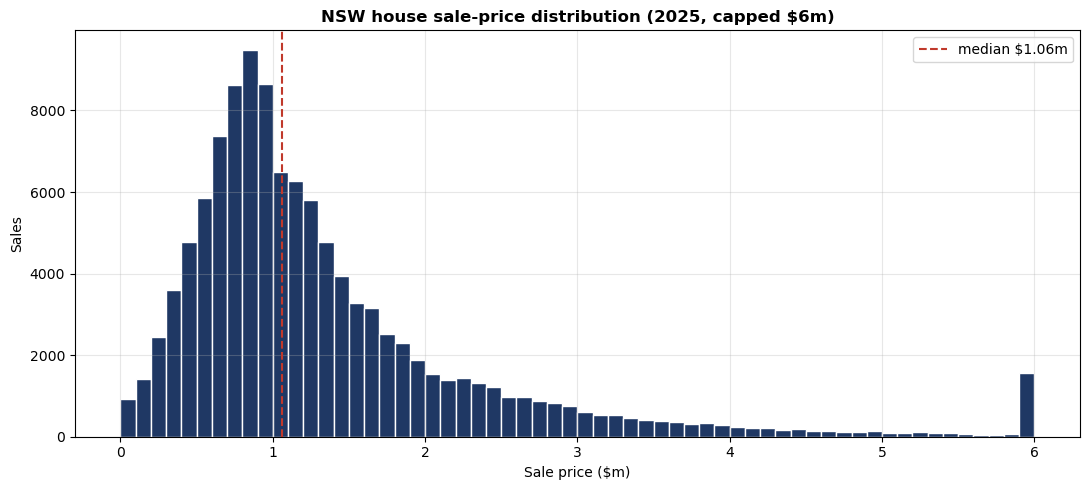

In [7]:
import matplotlib.pyplot as plt
conn = get_conn()
sales = pd.read_sql_query(
    "SELECT period, suburb, postcode, dwelling_type, price, area, area_type "
    "FROM sales WHERE price > 0 AND period LIKE '____-Q_'", conn)
conn.close()
sales["year"] = sales["period"].str[:4]
yr = sorted(sales["year"].unique())[-1]
h = sales[(sales.dwelling_type == "house") & (sales.year == yr)]

sub = h.groupby("suburb").agg(median=("price","median"), n=("price","size"))
sub = sub[sub.n >= 20].sort_values("median", ascending=False)
print(f"{yr}: {len(sub):,} suburbs with >=20 house sales.  Dearest vs cheapest = {sub['median'].max()/sub['median'].min():.0f}x")
print("\nDearest:");  print(sub.head(6).round(0).to_string())
print("\nCheapest:"); print(sub.tail(6).round(0).to_string())

print("\nNSW house price distribution (" + yr + "):")
for q in [0.05,0.25,0.5,0.75,0.95,0.99]:
    print(f"  {int(q*100):>2}th pct: ${h.price.quantile(q):>12,.0f}")

fig, ax = plt.subplots(figsize=(11,5))
ax.hist(np.clip(h.price/1e6, 0, 6), bins=60, color="#1F3864", edgecolor="white")
ax.axvline(h.price.median()/1e6, color="#c0392b", ls="--", label=f"median ${h.price.median()/1e6:.2f}m")
ax.set_title(f"NSW house sale-price distribution ({yr}, capped $6m)", fontweight="bold")
ax.set_xlabel("Sale price ($m)"); ax.set_ylabel("Sales"); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6 · Land value ($/m²) + postcode gross yields
Price-per-square-metre needs the land-area field (no other state's free data has it).

In [8]:
hl = h.copy()
hl["area_m2"] = np.where(hl.area_type.str.upper() == "H", hl.area*10000, hl.area)
hl = hl[(hl.area_m2 >= 100) & (hl.area_m2 <= 5000)]
hl["per_m2"] = hl.price / hl.area_m2
pm = hl.groupby("suburb").agg(per_m2=("per_m2","median"), n=("per_m2","size"))
pm = pm[pm.n >= 20].sort_values("per_m2", ascending=False)
print(f"Highest land value ($/m² of block), NSW median = ${hl.per_m2.median():,.0f}/m²:")
print(pm.head(8).round(0).to_string())

# postcode yields: VG sale price vs DCJ rent
conn = get_conn()
rent = pd.read_sql_query("SELECT region_type, region, dwelling_type, median_rent FROM rental_medians", conn)
conn.close()
sp = h.groupby("postcode")["price"].median().reset_index().rename(columns={"price":"median_price"})
rp = rent[(rent.region_type=="postcode") & (rent.dwelling_type.str.contains("House", case=False, na=False))]
rp = rp.groupby("region")["median_rent"].median().reset_index().rename(columns={"region":"postcode"})
rp["postcode"] = rp["postcode"].astype(str).str.replace(r"\.0$","",regex=True)
sp["postcode"] = sp["postcode"].astype(str)
y = sp.merge(rp, on="postcode", how="inner")
y["gross_yield_pct"] = (y.median_rent*52/y.median_price*100).round(2)
print(f"\n{len(y):,} postcodes matched. NSW median gross house yield: {y.gross_yield_pct.median():.2f}%")
print("Highest-yield postcodes:"); print(y.nlargest(6,"gross_yield_pct").to_string(index=False))

Highest land value ($/m² of block), NSW median = $1,778/m²:
                 per_m2    n
suburb                      
PADDINGTON      28634.0  206
DARLINGHURST    25974.0   38
DOUBLE BAY      24969.0   21
WOOLLAHRA       24631.0   82
SURRY HILLS     23121.0   55
MCMAHONS POINT  19763.0   21
BRONTE          19027.0   55
REDFERN         18791.0   66

410 postcodes matched. NSW median gross house yield: 3.21%
Highest-yield postcodes:
postcode  median_price  median_rent  gross_yield_pct
    2880      208000.0        350.0             8.75
    2820      340000.0        566.5             8.66
    2357      275000.0        395.0             7.47
    2660      350000.0        450.0             6.69
    2835      277500.0        355.0             6.65
    2710      350000.0        440.0             6.54


## 7 · Sydney vs the other capitals

  Sydney      $ 1,515k  (+163% since 2011-Q1)
  Melbourne   $   875k  (+80% since 2011-Q1)
  Brisbane    $ 1,100k  (+144% since 2011-Q1)
  Perth       $   951k  (+90% since 2011-Q1)
  Adelaide    $   950k  (+138% since 2011-Q1)


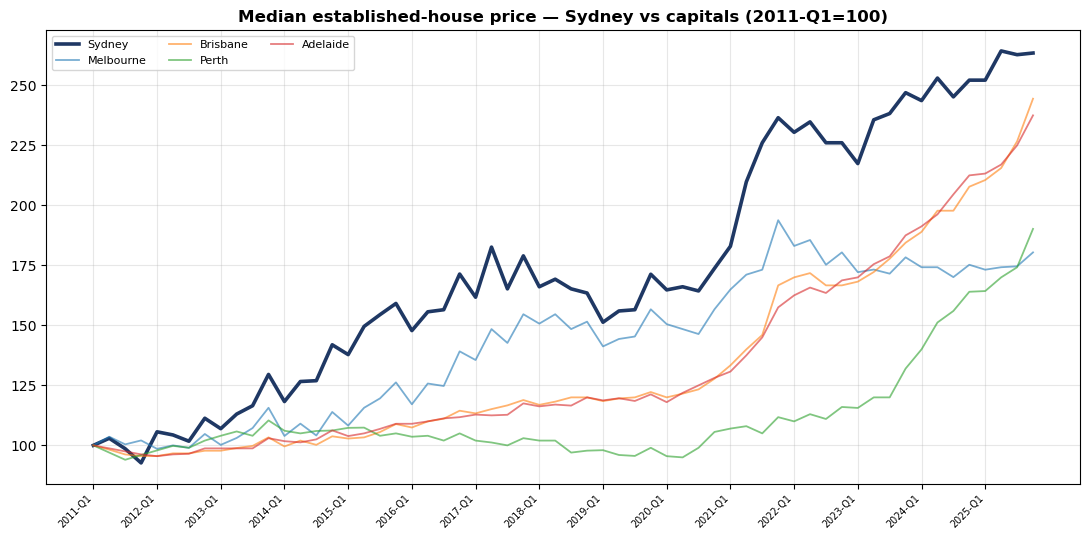

In [9]:
conn = get_conn()
cap = pd.read_sql_query("SELECT period, region, value FROM capital_prices WHERE measure='median_house' AND region LIKE 'Greater%'", conn)
conn.close()
piv = cap.pivot_table(index="period", columns="region", values="value").sort_index()
caps = [c for c in ["Greater Sydney","Greater Melbourne","Greater Brisbane","Greater Perth","Greater Adelaide"] if c in piv.columns]
base = piv[caps].dropna().index[0]
for c in caps:
    s = piv[c].dropna()
    print(f"  {c.replace('Greater ',''):11} ${s.iloc[-1]:>6,.0f}k  (+{(s.iloc[-1]/s.loc[base]-1)*100:.0f}% since {base})")
fig, ax = plt.subplots(figsize=(11,5.5))
for c in caps:
    s = piv[c].dropna(); s = s/s.loc[base]*100
    ax.plot(range(len(s)), s.values, label=c.replace("Greater ",""), lw=2.6 if c=="Greater Sydney" else 1.3,
            color="#1F3864" if c=="Greater Sydney" else None, alpha=1 if c=="Greater Sydney" else .6)
ax.set_xticks(range(0,len(piv.index),4)); ax.set_xticklabels(piv.index[::4], rotation=45, ha="right", fontsize=7)
ax.set_title(f"Median established-house price — Sydney vs capitals ({base}=100)", fontweight="bold")
ax.legend(fontsize=8, ncol=3); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

## 8 · Export — CSV + Excel dashboard

In [10]:
from nsw_housing import exports
exports.run()
import os
print("\nFiles in exports/:")
for f in sorted(os.listdir("exports")):
    p = f"exports/{f}"
    if os.path.isfile(p):
        print(f"  {f:<32} {os.path.getsize(p)/1024:.0f} KB")

2026-06-08 12:11:03 [INFO] nsw_housing.exports: Exporting CSVs...
2026-06-08 12:11:03 [INFO] nsw_housing.exports:   CSV: rental_medians.csv (5537 rows)
2026-06-08 12:11:03 [INFO] nsw_housing.exports:   CSV: building_approvals.csv (76 rows)
2026-06-08 12:11:03 [INFO] nsw_housing.exports:   CSV: lending_rates.csv (11220 rows)
2026-06-08 12:11:03 [INFO] nsw_housing.exports:   CSV: cash_rate.csv (430 rows)
2026-06-08 12:11:03 [INFO] nsw_housing.exports:   CSV: capital_prices.csv (3600 rows)
2026-06-08 12:11:03 [INFO] nsw_housing.exports:   CSV: asx_announcements.csv (48 rows)
2026-06-08 12:11:06 [INFO] nsw_housing.exports:   CSV: suburb_medians.csv (44,256 rows)
2026-06-08 12:11:06 [INFO] nsw_housing.exports: Building Excel dashboard...
2026-06-08 12:11:10 [INFO] nsw_housing.exports:   Sheet 'Suburb_Medians_Latest': 2888 rows
2026-06-08 12:11:10 [INFO] nsw_housing.exports:   Sheet 'Postcode_Yields': 408 rows
2026-06-08 12:11:11 [INFO] nsw_housing.exports: Excel dashboard saved: C:\Users\he


Files in exports/:
  .gitkeep                         0 KB
  asx_announcements.csv            4 KB
  building_approvals.csv           6 KB
  capital_prices.csv               249 KB
  cash_rate.csv                    17 KB
  lending_rates.csv                1496 KB
  nsw_housing_dashboard.xlsx       395 KB
  rental_medians.csv               410 KB
  suburb_medians.csv               1826 KB
